# Matched controller analysis

This notebook analyzes one completed greedy/look-ahead comparison from saved `run.json`, `installation_ticks.jsonl`, and `unit_ticks.jsonl` files. It never runs a simulation. Set `COMPARISON_ID` to a manifest ID to select a specific comparison; `None` selects the newest completed comparison.

In [1]:
import json
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from battery_fleet.comparison import list_completed_comparisons

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

COMPARISON_ID = None
cwd = Path.cwd().resolve()
REPO_ROOT = cwd if (cwd / "pyproject.toml").is_file() else cwd.parent
RUNS_DIR = REPO_ROOT / "runs"

## Select and load a completed comparison

The completion manifest is the source of truth for pairing runs. The following cell selects a completed pair, then reads only the saved summary and normalized detail files.

In [2]:
completed = list_completed_comparisons(RUNS_DIR)
if not completed:
    raise RuntimeError(f"No completed comparisons found under {RUNS_DIR}")

if COMPARISON_ID is None:
    selected = completed[0]
else:
    selected = next(
        (item for item in completed if item.comparison_id == COMPARISON_ID),
        None,
    )
    if selected is None:
        raise ValueError(f"Completed comparison not found: {COMPARISON_ID}")

run_dirs = {
    "greedy": selected.greedy_dir,
    "lookahead": selected.lookahead_dir,
}
summaries = {}
installation_parts = []
unit_parts = []
for expected_controller, run_dir in run_dirs.items():
    with (run_dir / "run.json").open(encoding="utf-8") as handle:
        summary = json.load(handle)
    summaries[expected_controller] = summary
    detail_files = summary["detail_files"]
    installation_parts.append(
        pd.read_json(run_dir / detail_files["installations"], lines=True)
    )
    unit_parts.append(pd.read_json(run_dir / detail_files["units"], lines=True))

installations = pd.concat(installation_parts, ignore_index=True)
units = pd.concat(unit_parts, ignore_index=True)
for frame in (installations, units):
    frame["time"] = pd.to_datetime(frame["time_unix"], unit="s", utc=True)

selection = pd.DataFrame(
    {
        "comparison_id": [selected.comparison_id] * 2,
        "controller": list(run_dirs),
        "run_id": [summaries[name]["id"] for name in run_dirs],
    }
)
display(selection)

,comparison_id,controller,run_id
0,20260902T113749.478503Z-5f1f24e09bdd44e69a3df4...,greedy,20260902T113749.478503Z-5f1f24e09bdd44e69a3df4...
1,20260902T113749.478503Z-5f1f24e09bdd44e69a3df4...,lookahead,20260902T113749.478503Z-5f1f24e09bdd44e69a3df4...


## Pair-integrity validation

These checks establish that the two controllers saw the same experiment: comparison ID, seed, step length, timestamps, prices, loads, outage sequence, and complete installation/unit topology must match. They also reject missing or duplicated detail rows.

In [3]:
controller_order = ["greedy", "lookahead"]
greedy_summary = summaries["greedy"]
lookahead_summary = summaries["lookahead"]

assert {summary["comparison_id"] for summary in summaries.values()} == {
    selected.comparison_id
}, "Run summaries must share the selected comparison ID."
assert {summary["controller"] for summary in summaries.values()} == set(
    controller_order
), "Run summaries must contain exactly greedy and lookahead."
assert greedy_summary["fleet_seed"] == lookahead_summary["fleet_seed"], (
    "Controller fleet seeds must match."
)
assert greedy_summary["dt_seconds"] == lookahead_summary["dt_seconds"], (
    "Controller step lengths must match."
)
assert greedy_summary["sites"] == lookahead_summary["sites"], (
    "Greedy and lookahead static site topology must be identical."
)
assert greedy_summary["units"] == lookahead_summary["units"], (
    "Greedy and lookahead static unit topology must be identical."
)

expected_sites = {site["id"] for site in greedy_summary["sites"]}
expected_unit_to_site = {
    unit["id"]: unit["site_id"] for unit in greedy_summary["units"]
}
expected_units = set(expected_unit_to_site)
assert len(expected_sites) == 80, "Static topology must contain 80 installations."
assert len(expected_units) == 100, "Static topology must contain 100 units."
assert set(expected_unit_to_site.values()) <= expected_sites, (
    "Every static unit must reference a static installation."
)
assert {
    unit_id
    for site in greedy_summary["sites"]
    for unit_id in site["unit_ids"]
} == expected_units, "Site unit lists must cover exactly the static units."

summary_ticks = {
    name: pd.DataFrame(summary["ticks"])
    for name, summary in summaries.items()
}
for column in ["time_unix", "price_usd_per_mwh", "load_w"]:
    np.testing.assert_allclose(
        summary_ticks["greedy"][column],
        summary_ticks["lookahead"][column],
        rtol=0,
        atol=1e-12,
        err_msg=f"Controller summary {column} values must match exactly.",
    )

assert set(installations["controller"]) == set(controller_order), (
    "Installation details must contain exactly greedy and lookahead."
)
assert set(units["controller"]) == set(controller_order), (
    "Unit details must contain exactly greedy and lookahead."
)

install_key = ["tick_index", "install_id"]
unit_key = ["tick_index", "unit_id"]
for controller in controller_order:
    summary = summaries[controller]
    install_rows = installations[installations["controller"] == controller]
    unit_rows = units[units["controller"] == controller]
    assert set(install_rows["comparison_id"]) == {selected.comparison_id}, (
        f"{controller}: installation rows must use the selected comparison ID."
    )
    assert set(unit_rows["comparison_id"]) == {selected.comparison_id}, (
        f"{controller}: unit rows must use the selected comparison ID."
    )
    assert set(install_rows["run_id"]) == {summary["id"]}, (
        f"{controller}: installation rows must use the summary run ID."
    )
    assert set(unit_rows["run_id"]) == {summary["id"]}, (
        f"{controller}: unit rows must use the summary run ID."
    )

    mapped_sites = unit_rows["unit_id"].map(expected_unit_to_site)
    assert mapped_sites.notna().all(), (
        f"{controller}: every detail unit ID must exist in static topology."
    )
    mapping_mismatch = unit_rows["install_id"] != mapped_sites
    assert not mapping_mismatch.any(), (
        f"{controller}: every unit detail row must match the static "
        "unit_id -> install_id mapping."
    )

    assert not install_rows.duplicated(install_key).any(), (
        f"{controller}: installation (tick_index, install_id) keys must be unique."
    )
    assert not unit_rows.duplicated(unit_key).any(), (
        f"{controller}: unit (tick_index, unit_id) keys must be unique."
    )

    tick_count = len(summary["ticks"])
    expected_install_keys = pd.MultiIndex.from_product(
        [range(tick_count), sorted(expected_sites)], names=install_key
    )
    actual_install_keys = pd.MultiIndex.from_frame(
        install_rows[install_key]
    ).sort_values()
    missing_install_keys = expected_install_keys.difference(actual_install_keys)
    extra_install_keys = actual_install_keys.difference(expected_install_keys)
    assert actual_install_keys.equals(expected_install_keys), (
        f"{controller}: installation details must contain every expected "
        f"tick/site combination exactly once; missing={len(missing_install_keys)}, "
        f"extra={len(extra_install_keys)}."
    )

    expected_unit_keys = pd.MultiIndex.from_product(
        [range(tick_count), sorted(expected_units)], names=unit_key
    )
    actual_unit_keys = pd.MultiIndex.from_frame(unit_rows[unit_key]).sort_values()
    missing_unit_keys = expected_unit_keys.difference(actual_unit_keys)
    extra_unit_keys = actual_unit_keys.difference(expected_unit_keys)
    assert actual_unit_keys.equals(expected_unit_keys), (
        f"{controller}: unit details must contain every expected tick/unit "
        f"combination exactly once; missing={len(missing_unit_keys)}, "
        f"extra={len(extra_unit_keys)}."
    )

    expected_time_by_tick = pd.Series(
        [tick["time_unix"] for tick in summary["ticks"]],
        index=range(tick_count),
    )
    install_expected_times = install_rows["tick_index"].map(expected_time_by_tick)
    unit_expected_times = unit_rows["tick_index"].map(expected_time_by_tick)
    assert install_expected_times.notna().all(), (
        f"{controller}: every installation tick index must exist in the summary."
    )
    assert unit_expected_times.notna().all(), (
        f"{controller}: every unit tick index must exist in the summary."
    )
    assert np.array_equal(
        install_rows["time_unix"].to_numpy(),
        install_expected_times.to_numpy(),
    ), f"{controller}: installation tick timestamps must exactly match the summary."
    assert np.array_equal(
        unit_rows["time_unix"].to_numpy(),
        unit_expected_times.to_numpy(),
    ), f"{controller}: unit tick timestamps must exactly match the summary."

greedy_install = installations[installations["controller"] == "greedy"].sort_values(
    install_key
)
lookahead_install = installations[
    installations["controller"] == "lookahead"
].sort_values(install_key)
assert greedy_install[install_key].reset_index(drop=True).equals(
    lookahead_install[install_key].reset_index(drop=True)
), "Controller installation detail keys must match."
np.testing.assert_allclose(
    greedy_install[["time_unix", "load_w"]],
    lookahead_install[["time_unix", "load_w"]],
    rtol=0,
    atol=1e-12,
    err_msg="Controller installation timestamps and loads must match exactly.",
)

def unreachable_sequence(frame):
    return [
        tuple(sorted(group.loc[~group["reachable"], "unit_id"]))
        for _, group in frame.groupby("tick_index", sort=True)
    ]

assert unreachable_sequence(units[units["controller"] == "greedy"]) == (
    unreachable_sequence(units[units["controller"] == "lookahead"])
), "Controller unreachable-unit sequences must match."
print(
    f"Validated exact topology and detail coverage for "
    f"{len(summary_ticks['greedy'])} ticks, {len(expected_sites)} installations, "
    f"and {len(expected_units)} units for greedy and lookahead."
)

Validated exact topology and detail coverage for 96 ticks, 80 installations, and 100 units for greedy and lookahead.


## Daily unit profit contribution

Each value is one unit's full-day sum of wholesale contribution plus customer-payment change minus wear and tracking penalty. Identical bin edges and x-limits make the controller distributions directly comparable; vertical lines mark zero and each controller's mean.

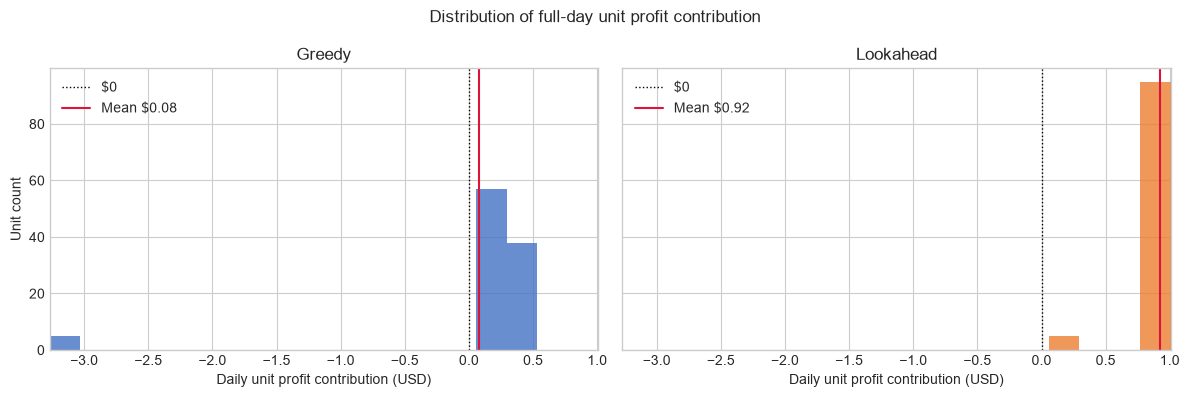

In [4]:
unit_daily = (
    units.groupby(["controller", "unit_id"], as_index=False)[
        "profit_contribution_usd"
    ]
    .sum()
    .rename(columns={"profit_contribution_usd": "unit_profit_usd"})
)
unit_values = unit_daily["unit_profit_usd"].to_numpy()
unit_bins = np.histogram_bin_edges(unit_values, bins="auto")
unit_xlim = (unit_bins[0], unit_bins[-1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for axis, controller in zip(axes, controller_order):
    values = unit_daily.loc[
        unit_daily["controller"] == controller, "unit_profit_usd"
    ]
    axis.hist(values, bins=unit_bins, color={"greedy": "#4472C4", "lookahead": "#ED7D31"}[controller], alpha=0.8)
    axis.axvline(0, color="black", linewidth=1, linestyle=":", label="$0")
    axis.axvline(values.mean(), color="crimson", linewidth=1.5, label=f"Mean ${values.mean():.2f}")
    axis.set_title(controller.title())
    axis.set_xlabel("Daily unit profit contribution (USD)")
    axis.set_xlim(unit_xlim)
    axis.legend()
axes[0].set_ylabel("Unit count")
fig.suptitle("Distribution of full-day unit profit contribution")
fig.tight_layout()
plt.show()

## Daily installation customer bills

Each value is one installation's full-day retail bill. Both controller panels use identical bins and x-limits; the dashed reference is the corresponding full-day bill with no battery.

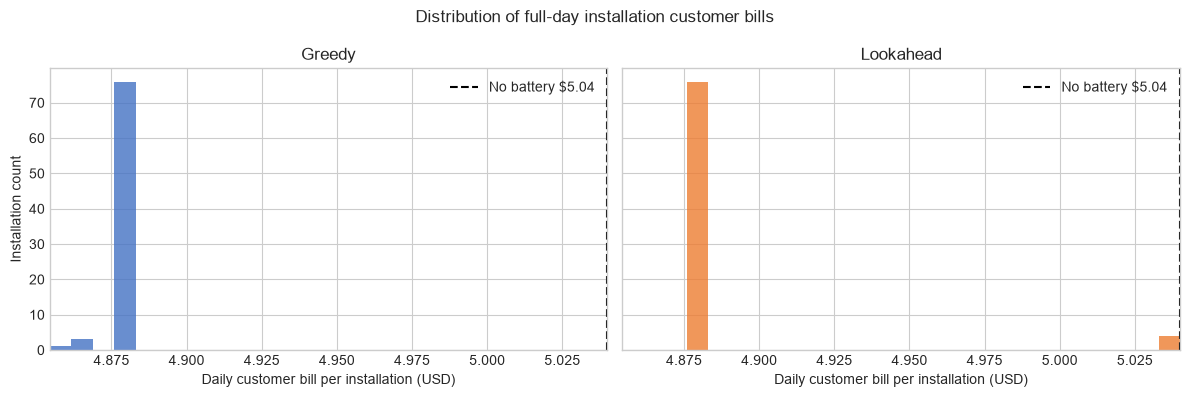

In [5]:
installation_daily = installations.groupby(
    ["controller", "install_id"], as_index=False
)[["customer_bill_usd", "no_battery_customer_bill_usd"]].sum()
bill_values = installation_daily["customer_bill_usd"].to_numpy()
bill_bins = np.histogram_bin_edges(bill_values, bins="auto")
bill_xlim = (
    min(bill_bins[0], installation_daily["no_battery_customer_bill_usd"].min()),
    max(bill_bins[-1], installation_daily["no_battery_customer_bill_usd"].max()),
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for axis, controller in zip(axes, controller_order):
    rows = installation_daily[installation_daily["controller"] == controller]
    baseline = rows["no_battery_customer_bill_usd"].iloc[0]
    np.testing.assert_allclose(rows["no_battery_customer_bill_usd"], baseline)
    axis.hist(
        rows["customer_bill_usd"],
        bins=bill_bins,
        color={"greedy": "#4472C4", "lookahead": "#ED7D31"}[controller],
        alpha=0.8,
    )
    axis.axvline(
        baseline,
        color="black",
        linewidth=1.5,
        linestyle="--",
        label=f"No battery ${baseline:.2f}",
    )
    axis.set_title(controller.title())
    axis.set_xlabel("Daily customer bill per installation (USD)")
    axis.set_xlim(bill_xlim)
    axis.legend()
axes[0].set_ylabel("Installation count")
fig.suptitle("Distribution of full-day installation customer bills")
fig.tight_layout()
plt.show()

## Unit state of charge

Every unit is drawn as a faint trajectory in its controller subplot. The solid line is the 100-unit mean and the shaded band is mean ± one population standard deviation; shared axes expose timing and dispersion differences.

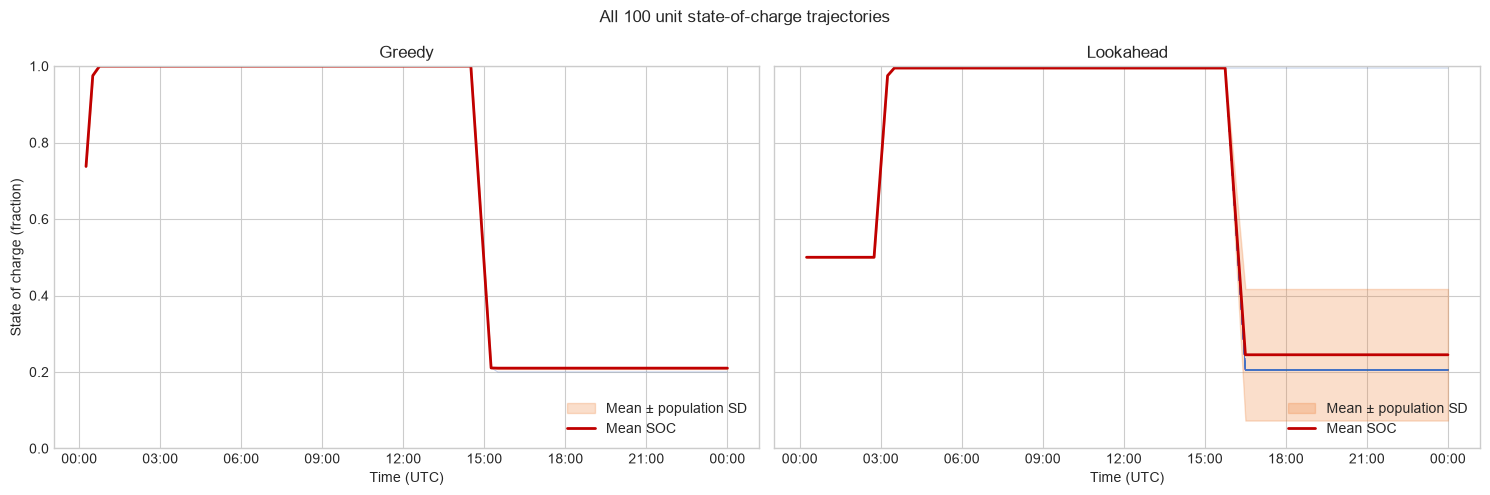

In [6]:
soc_times = pd.to_datetime(
    summary_ticks["greedy"]["time_unix"], unit="s", utc=True
)
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)
for axis, controller in zip(axes, controller_order):
    pivot = units[units["controller"] == controller].pivot(
        index="time", columns="unit_id", values="soc"
    ).sort_index()
    assert pivot.shape == (len(soc_times), 100)
    axis.plot(pivot.index, pivot, color="#4472C4", alpha=0.08, linewidth=0.6)
    mean = pivot.mean(axis=1)
    std = pivot.std(axis=1, ddof=0)
    axis.fill_between(
        pivot.index,
        (mean - std).clip(0, 1),
        (mean + std).clip(0, 1),
        color="#ED7D31",
        alpha=0.25,
        label="Mean ± population SD",
    )
    axis.plot(pivot.index, mean, color="#C00000", linewidth=2, label="Mean SOC")
    axis.set_title(controller.title())
    axis.set_xlabel("Time (UTC)")
    axis.set_ylim(0, 1)
    axis.legend(loc="lower right")
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pivot.index.tz))
axes[0].set_ylabel("State of charge (fraction)")
fig.suptitle("All 100 unit state-of-charge trajectories")
fig.tight_layout()
plt.show()

## Installation power

Each controller gets a complete 8-column × 10-row small-multiple figure containing all 80 installations. Every panel shows house load, battery power, and grid power in watts on common time and power axes within that controller figure; no sites are sampled.

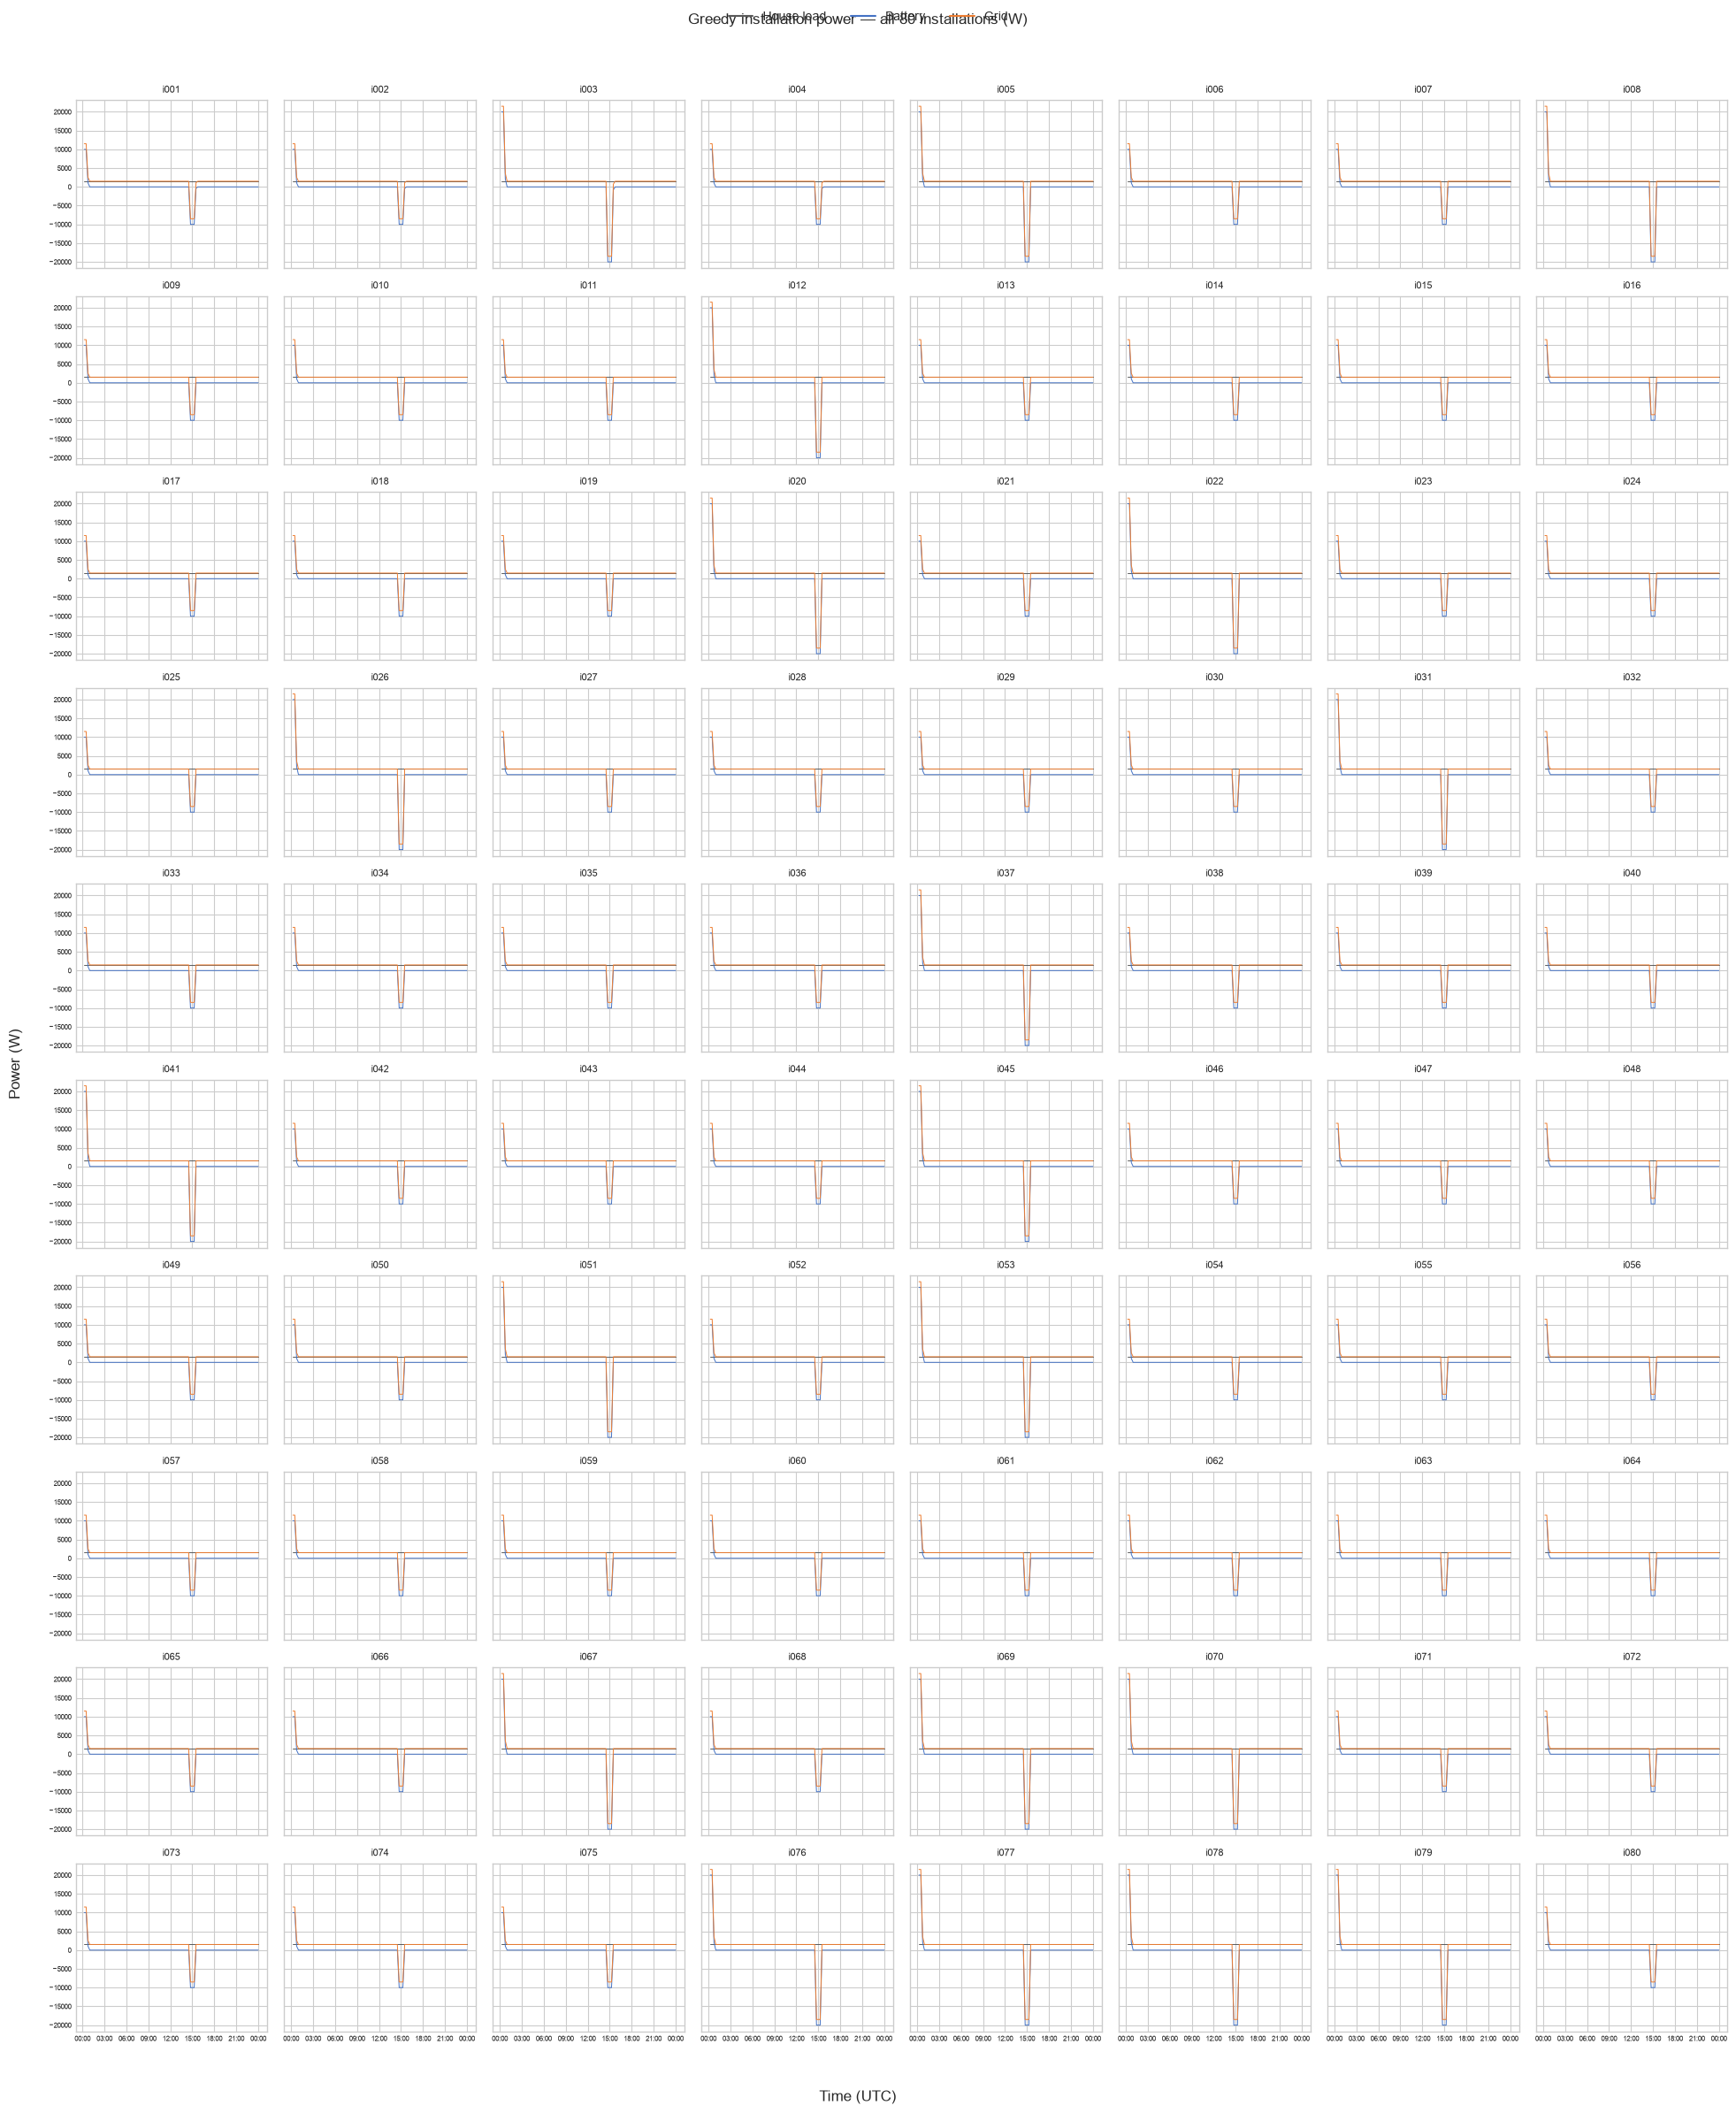

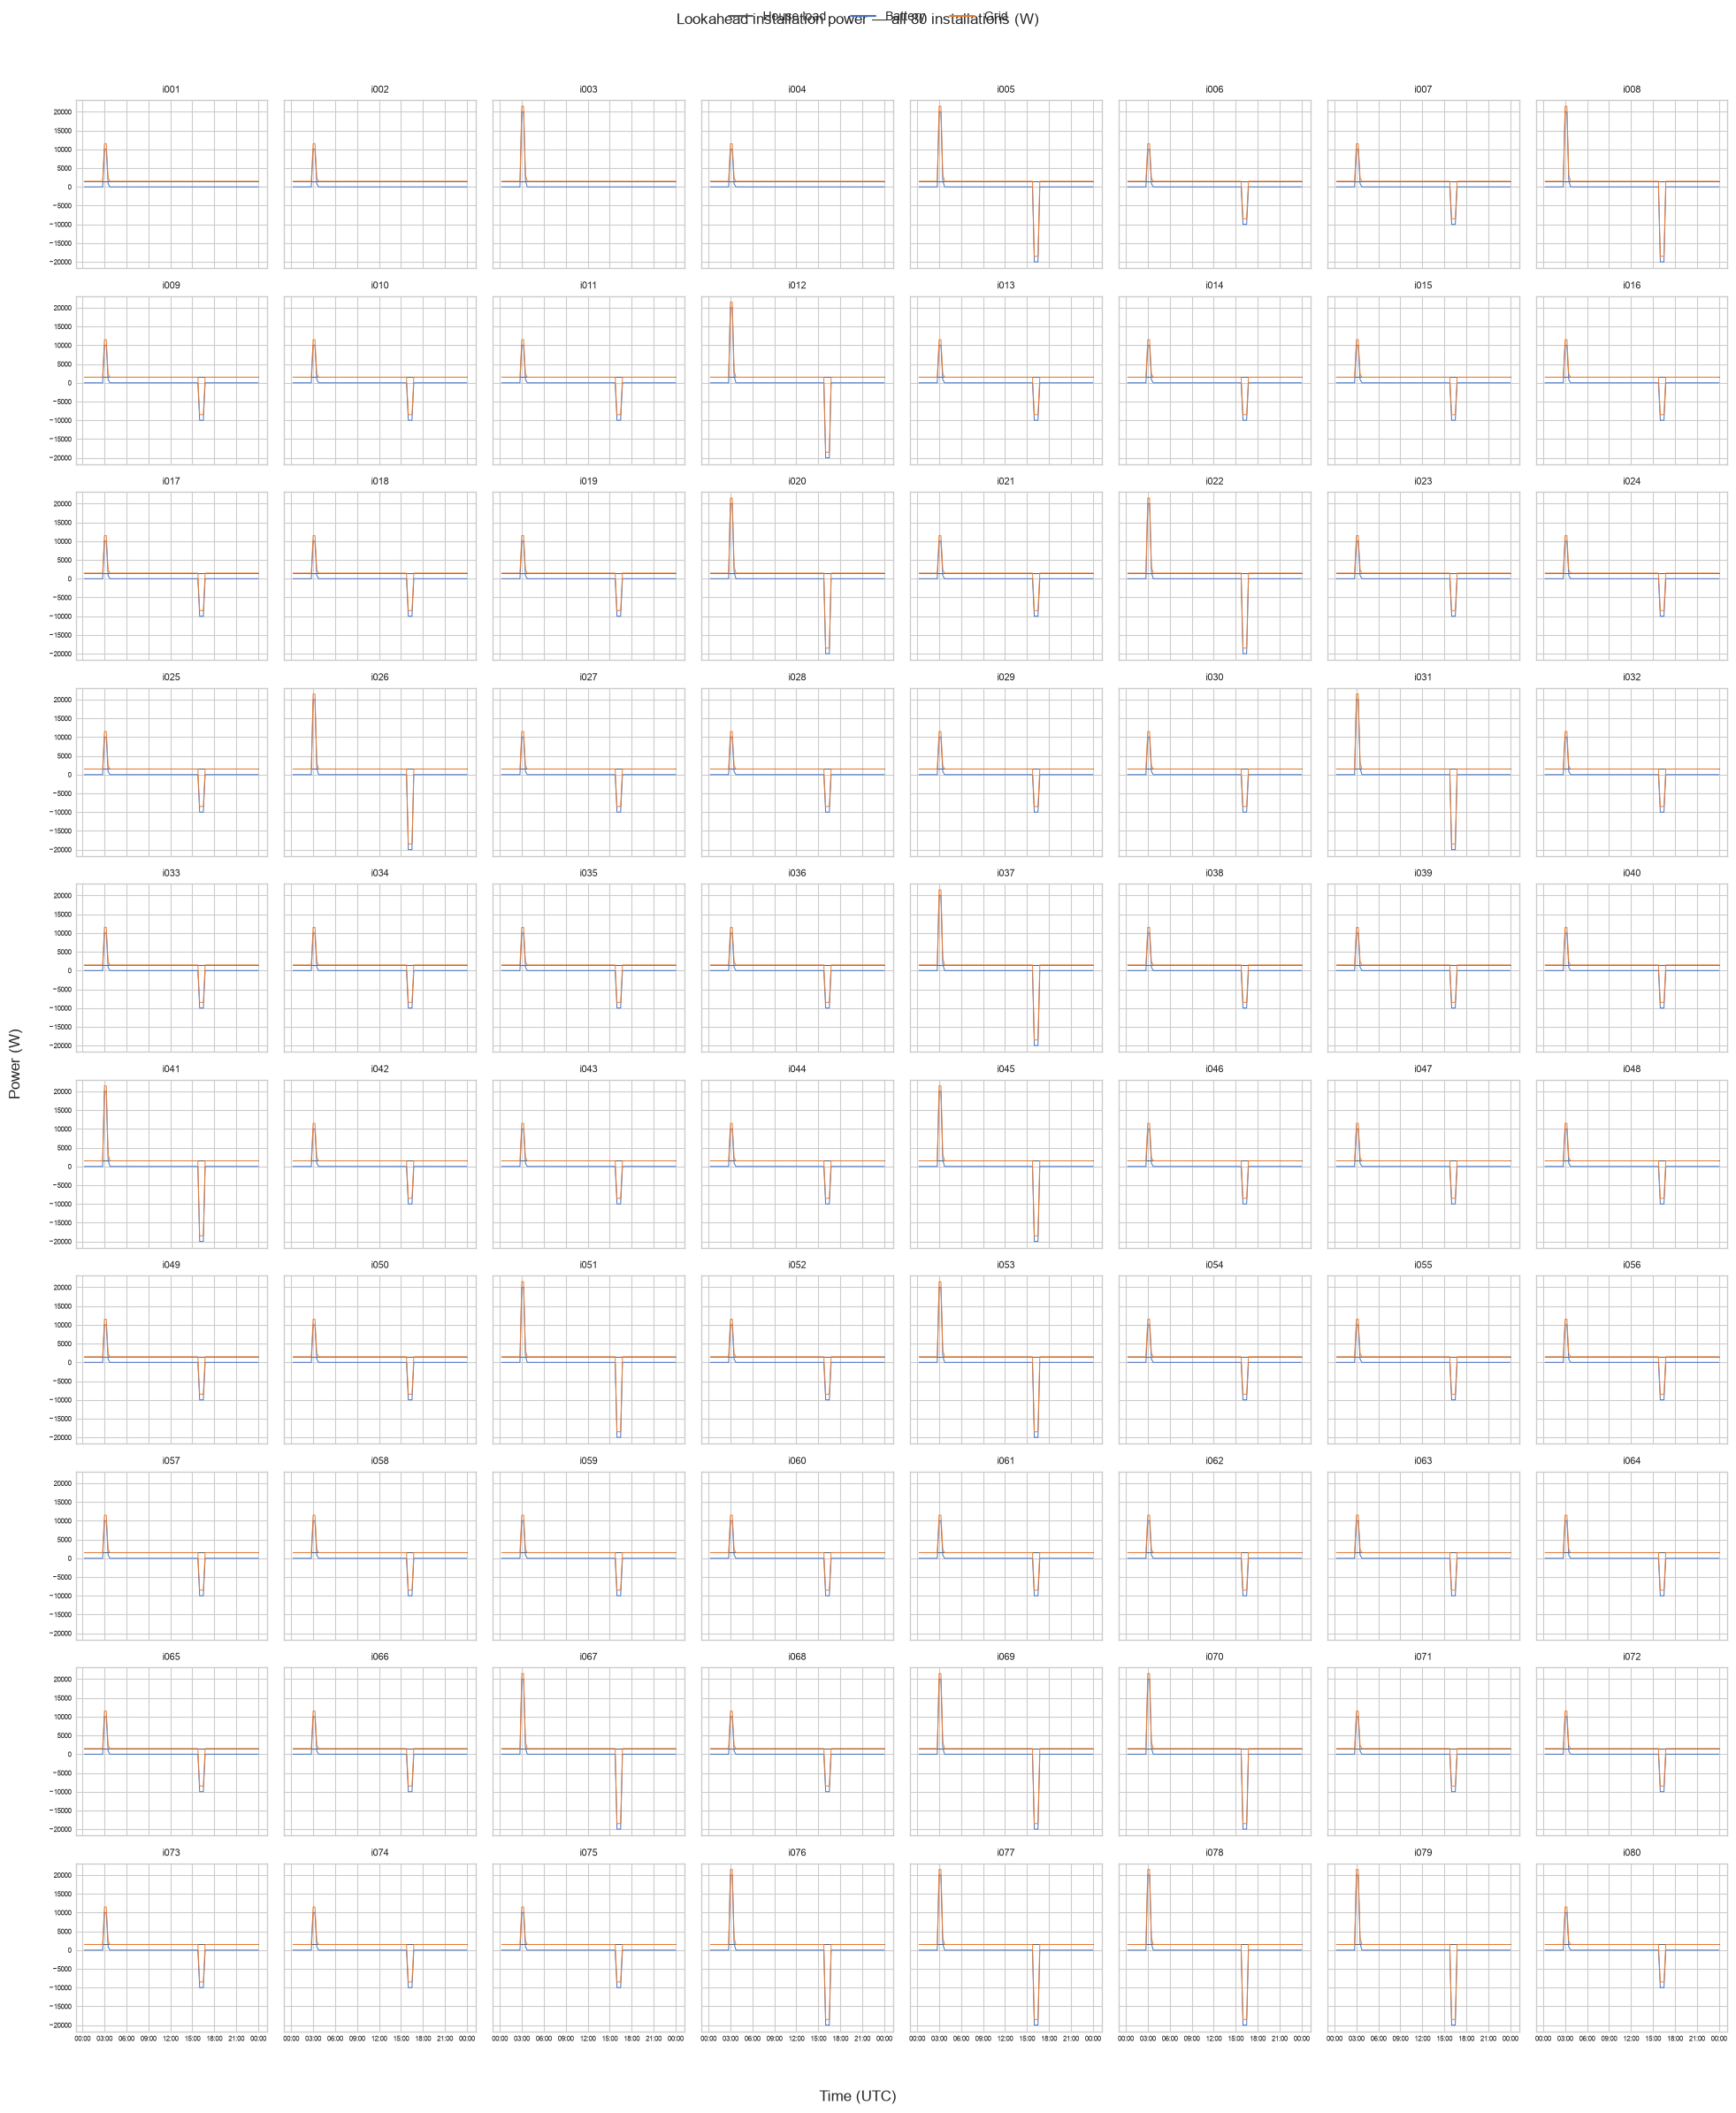

In [7]:
power_colors = {"load_w": "#595959", "battery_w": "#4472C4", "grid_w": "#ED7D31"}
power_labels = {"load_w": "House load", "battery_w": "Battery", "grid_w": "Grid"}
installation_ids = sorted(expected_sites)

for controller in controller_order:
    rows = installations[installations["controller"] == controller]
    y_min = rows[["load_w", "battery_w", "grid_w"]].min().min()
    y_max = rows[["load_w", "battery_w", "grid_w"]].max().max()
    padding = max((y_max - y_min) * 0.04, 1)
    fig, axes = plt.subplots(
        10,
        8,
        figsize=(20, 24),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    for axis, install_id in zip(axes.flat, installation_ids):
        site = rows[rows["install_id"] == install_id].sort_values("time")
        assert len(site) == len(summary_ticks[controller])
        for column in ["load_w", "battery_w", "grid_w"]:
            axis.plot(
                site["time"],
                site[column],
                color=power_colors[column],
                linewidth=0.7,
                label=power_labels[column],
            )
        axis.set_title(install_id, fontsize=8)
        axis.set_ylim(y_min - padding, y_max + padding)
        axis.tick_params(labelsize=6)
        axis.xaxis.set_major_formatter(
            mdates.DateFormatter("%H:%M", tz=site["time"].dt.tz)
        )
    handles = [
        plt.Line2D([], [], color=power_colors[column], label=power_labels[column])
        for column in power_colors
    ]
    fig.legend(handles=handles, loc="upper center", ncol=3, frameon=False)
    fig.suptitle(
        f"{controller.title()} installation power — all 80 installations (W)",
        y=0.995,
    )
    fig.supxlabel("Time (UTC)")
    fig.supylabel("Power (W)")
    fig.tight_layout(rect=(0.02, 0.02, 1, 0.98))
    plt.show()

## Wholesale price versus fleet demand

The time series aligns wholesale price with total house load and each controller's total grid demand. The scatter removes time and shows how grid demand responds at each wholesale price, with one color per controller.

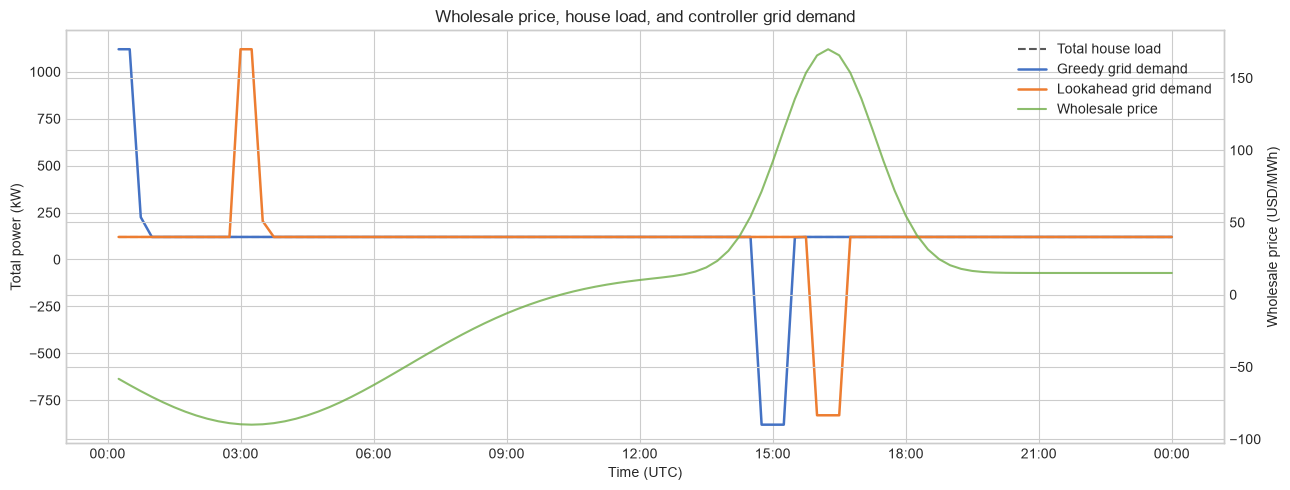

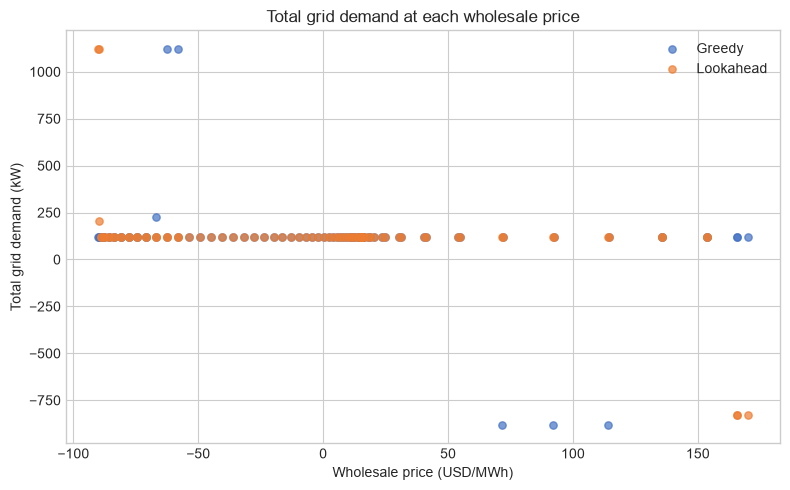

In [8]:
fleet_series = {}
for controller in controller_order:
    frame = summary_ticks[controller].copy()
    frame["time"] = pd.to_datetime(frame["time_unix"], unit="s", utc=True)
    frame["total_grid_w"] = frame["load_w"] + frame["fleet_w"]
    fleet_series[controller] = frame

fig, demand_axis = plt.subplots(figsize=(13, 5))
price_axis = demand_axis.twinx()
base = fleet_series["greedy"]
demand_axis.plot(base["time"], base["load_w"] / 1_000, color="#595959", linestyle="--", label="Total house load")
for controller, color in zip(controller_order, ["#4472C4", "#ED7D31"]):
    frame = fleet_series[controller]
    demand_axis.plot(frame["time"], frame["total_grid_w"] / 1_000, color=color, linewidth=1.8, label=f"{controller.title()} grid demand")
price_axis.plot(base["time"], base["price_usd_per_mwh"], color="#70AD47", linewidth=1.5, alpha=0.8, label="Wholesale price")
demand_axis.set_title("Wholesale price, house load, and controller grid demand")
demand_axis.set_xlabel("Time (UTC)")
demand_axis.set_ylabel("Total power (kW)")
price_axis.set_ylabel("Wholesale price (USD/MWh)")
demand_axis.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=base["time"].dt.tz))
handles_a, labels_a = demand_axis.get_legend_handles_labels()
handles_b, labels_b = price_axis.get_legend_handles_labels()
demand_axis.legend(handles_a + handles_b, labels_a + labels_b, loc="best")
fig.tight_layout()
plt.show()

fig, axis = plt.subplots(figsize=(8, 5))
for controller, color in zip(controller_order, ["#4472C4", "#ED7D31"]):
    frame = fleet_series[controller]
    axis.scatter(
        frame["price_usd_per_mwh"],
        frame["total_grid_w"] / 1_000,
        s=28,
        alpha=0.7,
        color=color,
        label=controller.title(),
    )
axis.set_title("Total grid demand at each wholesale price")
axis.set_xlabel("Wholesale price (USD/MWh)")
axis.set_ylabel("Total grid demand (kW)")
axis.legend()
fig.tight_layout()
plt.show()

## Controller summary

The final table totals installation-level economics and reports the distribution of full-day unit profit contributions. Customer savings are the no-battery customer bill minus the actual customer bill; wear is degradation cost and tracking penalty is missed-delivery cost.

In [9]:
summary_rows = []
for controller in controller_order:
    install_rows = installations[installations["controller"] == controller]
    unit_profit = unit_daily.loc[
        unit_daily["controller"] == controller, "unit_profit_usd"
    ]
    customer_bill = install_rows["customer_bill_usd"].sum()
    no_battery_bill = install_rows["no_battery_customer_bill_usd"].sum()
    summary_rows.append(
        {
            "controller": controller,
            "company_profit_usd": install_rows["company_profit_usd"].sum(),
            "customer_bill_usd": customer_bill,
            "no_battery_customer_bill_usd": no_battery_bill,
            "customer_savings_usd": no_battery_bill - customer_bill,
            "wholesale_settlement_usd": install_rows["wholesale_pnl_usd"].sum(),
            "wear_usd": install_rows["degradation_cost_usd"].sum(),
            "tracking_penalty_usd": install_rows["tracking_penalty_usd"].sum(),
            "unit_profit_mean_usd": unit_profit.mean(),
            "unit_profit_std_usd": unit_profit.std(ddof=0),
            "unit_profit_min_usd": unit_profit.min(),
            "unit_profit_max_usd": unit_profit.max(),
        }
    )
controller_summary = pd.DataFrame(summary_rows).set_index("controller")
assert controller_summary.notna().all().all()
display(controller_summary)

,company_profit_usd,customer_bill_usd,no_battery_customer_bill_usd,customer_savings_usd,wholesale_settlement_usd,wear_usd,tracking_penalty_usd,unit_profit_mean_usd,unit_profit_std_usd,unit_profit_min_usd,unit_profit_max_usd
controller,,,,,,,,,,,
greedy,408.6904,390.5300,403.2000,12.6700,99.4012,63.8408,17.4000,0.0751,0.7606,-3.2676,0.2966
lookahead,493.3789,391.2300,403.2000,11.9700,163.8265,61.6776,0.0000,0.9220,0.1681,0.2077,1.0068


In [10]:
assert set(unit_daily["controller"]) == set(controller_order)
assert unit_daily.groupby("controller")["unit_id"].nunique().eq(100).all()
assert installation_daily.groupby("controller")["install_id"].nunique().eq(80).all()
assert controller_summary.shape == (2, 11)
print(
    "NOTEBOOK_VERIFICATION: outputs populated; controllers=2; "
    "units_per_controller=100; installations_per_controller=80; "
    f"comparison_id={selected.comparison_id}"
)

NOTEBOOK_VERIFICATION: outputs populated; controllers=2; units_per_controller=100; installations_per_controller=80; comparison_id=20260902T113749.478503Z-5f1f24e09bdd44e69a3df451e32f6c4f
